Download Email spam classification dataset from Kaggle 
https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv.   
Email Spam detection has two states: a) Normal State – Not Spam, b) Abnormal State – Spam. Use K
Nearest Neighbors and Support Vector Machine to classify the email. Extract confusion matrix from 
the test results and compare the performance of both.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
df = pd.read_csv("emails.csv")

In [3]:
df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [4]:
df = df.select_dtypes(include=['number'])

In [5]:
df.isnull().sum().all()

np.False_

In [6]:
X = df.drop(columns=['Prediction'])
y = df['Prediction']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# ---- Text Vectorization ----
vectorizer = CountVectorizer(stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [10]:
print("🔹 KNN Results")
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)
print(classification_report(y_test, y_pred_knn))

🔹 KNN Results
Accuracy: 0.863768115942029
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       739
           1       0.73      0.84      0.78       296

    accuracy                           0.86      1035
   macro avg       0.83      0.86      0.84      1035
weighted avg       0.87      0.86      0.87      1035



In [11]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [12]:
print("\n🔹 SVM Results")
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy_svm)
print(classification_report(y_test, y_pred_svm))


🔹 SVM Results
Accuracy: 0.9594202898550724
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       739
           1       0.92      0.94      0.93       296

    accuracy                           0.96      1035
   macro avg       0.95      0.95      0.95      1035
weighted avg       0.96      0.96      0.96      1035



In [16]:
print("\n* Model Comparison Summary *")

if accuracy_knn > accuracy_svm:
    print(f"KNN performed better with an accuracy of {accuracy_knn:.2f} "
          f"compared to SVM’s {accuracy_svm:.2f}.")
elif accuracy_svm > accuracy_knn:
    print(f"SVM performed better with an accuracy of {accuracy_svm:.2f} "
          f"compared to KNN’s {accuracy_knn:.2f}.")
else:
    print(f"Both models performed equally well with an accuracy of {accuracy_knn:.2f}.")


* Model Comparison Summary *
SVM performed better with an accuracy of 0.96 compared to KNN’s 0.86.


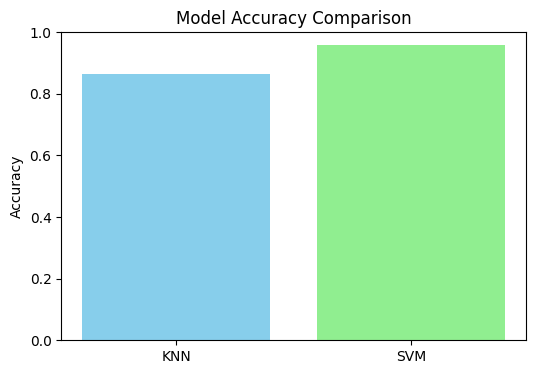

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(['KNN', 'SVM'], [accuracy_knn, accuracy_svm], color=['skyblue', 'lightgreen'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

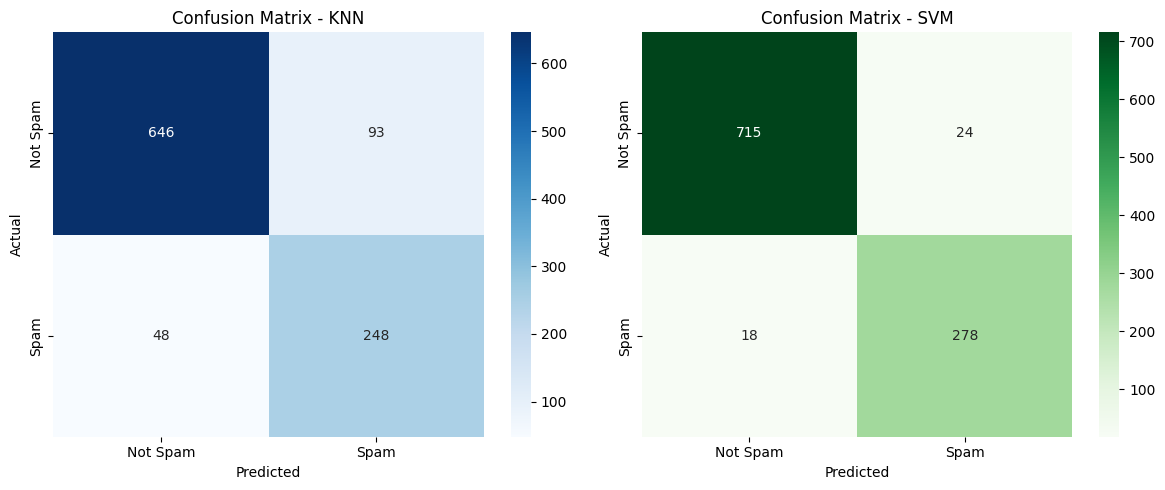

In [18]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
axes[0].set_title("Confusion Matrix - KNN")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
axes[1].set_title("Confusion Matrix - SVM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [15]:

# ---- Predict on New Emails ----
import pandas as pd

# Get all feature column names from your training data
feature_columns = X.columns.tolist()

# Create 3 new emails as examples
new_emails = [
    "Get a free iPhone now!",
    "Important meeting agenda for today",
    "You've won a vacation package!",
    "Please find the project report attached for review."
]

# Create empty DataFrame with same columns (filled with 0)
new_email_data = pd.DataFrame(0, index=range(len(new_emails)), columns=feature_columns)

# Set some word-based features manually (these words should exist as columns)
for i, email in enumerate(new_emails):
    email_lower = email.lower()
    for word in feature_columns:
        if word in email_lower:
            new_email_data.loc[i, word] = 1  # mark presence of that word

# ---- Predict using trained models ----
knn_predictions = knn.predict(new_email_data)
svm_predictions = svm.predict(new_email_data)

# ---- Print Results ----
print("🔹 KNN Predictions:")
for email, pred in zip(new_emails, knn_predictions):
    print(f"Email: '{email}' → classified as {'SPAM' if pred == 1 else 'NOT SPAM'}")

print("\n🔹 SVM Predictions:")
for email, pred in zip(new_emails, svm_predictions):
    print(f"Email: '{email}' → classified as {'SPAM' if pred == 1 else 'NOT SPAM'}")



🔹 KNN Predictions:
Email: 'Get a free iPhone now!' → classified as SPAM
Email: 'Important meeting agenda for today' → classified as SPAM
Email: 'You've won a vacation package!' → classified as SPAM
Email: 'Please find the project report attached for review.' → classified as SPAM

🔹 SVM Predictions:
Email: 'Get a free iPhone now!' → classified as SPAM
Email: 'Important meeting agenda for today' → classified as SPAM
Email: 'You've won a vacation package!' → classified as SPAM
Email: 'Please find the project report attached for review.' → classified as NOT SPAM
